## 1) load library

In [2]:
import time
import os
import json
import argparse

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from skimage.transform import resize

import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim
import torch.utils.data
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
import torchvision.transforms as transforms

from datasets import CaptionDataset
from models import Encoder, DecoderWithAttention
from utils import *
from nltk.translate.bleu_score import corpus_bleu
from tqdm import tqdm
import imageio

## 2) Data processing

### Input file generation for image captioning

In [3]:
from utils import create_input_files

create_input_files(dataset='flickr8k',
                   karpathy_json_path='/kaggle/working/captioning-dataset/caption_datasets/dataset_flickr8k.json',
                   image_folder='/kaggle/working/captioning-dataset/Flickr8k_Dataset/Flicker8k_Dataset',
                   captions_per_image=5,
                   min_word_freq=5,
                   output_folder='/kaggle/working/captioning-dataset/Flickr8k_Dataset',
                   max_len=100)



Reading TRAIN images and captions, storing to file...



100%|██████████| 6000/6000 [00:39<00:00, 152.03it/s]



Reading VAL images and captions, storing to file...



100%|██████████| 1000/1000 [00:06<00:00, 152.19it/s]



Reading TEST images and captions, storing to file...



100%|██████████| 1000/1000 [00:06<00:00, 149.55it/s]


### set config

In [4]:
# Data parameters
data_folder = '/kaggle/working/captioning-dataset/Flickr8k_Dataset'  
data_name = 'flickr8k_5_cap_per_img_5_min_word_freq' 

# Model parameters
emb_dim = 512  
attention_dim = 512  
decoder_dim = 512  
dropout = 0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  
cudnn.benchmark = True  

# Training parameters
start_epoch = 0
epochs = 5 
epochs_since_improvement = 0  
batch_size = 64
workers = 2  
encoder_lr = 1e-4  
decoder_lr = 4e-4 
grad_clip = 5.  
alpha_c = 1.  
best_bleu4 = 0.  
print_freq = 100  
fine_tune_encoder = False  
checkpoint = None

### load data

In [5]:
word_map_file = os.path.join(data_folder, 'WORDMAP_' + data_name + '.json')
with open(word_map_file, 'r') as j:
    word_map = json.load(j)
print(word_map)

{'a': 1, 'black': 2, 'dog': 3, 'is': 4, 'running': 5, 'after': 6, 'white': 7, 'in': 8, 'the': 9, 'snow': 10, 'chasing': 11, 'brown': 12, 'through': 13, 'two': 14, 'dogs': 15, 'chase': 16, 'each': 17, 'other': 18, 'across': 19, 'snowy': 20, 'ground': 21, 'play': 22, 'together': 23, 'low': 24, 'lying': 25, 'body': 26, 'of': 27, 'water': 28, 'little': 29, 'baby': 30, 'plays': 31, 'girl': 32, 'next': 33, 'to': 34, 'truck': 35, 'child': 36, 'playing': 37, 'by': 38, 'kid': 39, 'front': 40, 'car': 41, 'with': 42, 'put': 43, 'and': 44, 'ball': 45, 'boy': 46, 'beside': 47, 'has': 48, 'something': 49, 'hot': 50, 'pink': 51, 'its': 52, 'mouth': 53, 'holding': 54, 'hat': 55, 'shirt': 56, 'carrying': 57, 'while': 58, 'walking': 59, 'looking': 60, 'forward': 61, 'along': 62, 'beach': 63, 'wearing': 64, 'collar': 65, 'walks': 66, 'on': 67, 'sand': 68, 'near': 69, 'large': 70, 'ocean': 71, 'red': 72, 'frisbee': 73, 'standing': 74, 'sandy': 75, 'disc': 76, 'flying': 77, 'air': 78, 'catching': 79, 'drop

In [6]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_loader = torch.utils.data.DataLoader(CaptionDataset(data_folder, data_name, 'TRAIN', transform=transforms.Compose([normalize])), batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True)
val_loader = torch.utils.data.DataLoader( CaptionDataset(data_folder, data_name, 'VAL', transform=transforms.Compose([normalize])),batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 3) Train model

### define function for train & validate

In [7]:
def train(train_loader, encoder, decoder, criterion, encoder_optimizer, decoder_optimizer, epoch):

    decoder.train()  
    encoder.train()

    batch_time = AverageMeter()  
    data_time = AverageMeter() 
    losses = AverageMeter()  
    top5accs = AverageMeter() 

    start = time.time()

    for i, (imgs, caps, caplens) in enumerate(train_loader):
        data_time.update(time.time() - start)

        imgs = imgs.to(device)
        caps = caps.to(device)
        caplens = caplens.to(device)

        imgs = encoder(imgs)
        scores, caps_sorted, decode_lengths, alphas, sort_ind = decoder(imgs, caps, caplens)

        targets = caps_sorted[:, 1:]

        scores, *_ = pack_padded_sequence(scores, decode_lengths, batch_first=True)
        targets, *_ = pack_padded_sequence(targets, decode_lengths, batch_first=True)

        loss = criterion(scores, targets)

        loss += alpha_c * ((1. - alphas.sum(dim=1)) ** 2).mean()

        decoder_optimizer.zero_grad()
        if encoder_optimizer is not None:
            encoder_optimizer.zero_grad()
        loss.backward()

        if grad_clip is not None:
            clip_gradient(decoder_optimizer, grad_clip)
            if encoder_optimizer is not None:
                clip_gradient(encoder_optimizer, grad_clip)

        decoder_optimizer.step()
        if encoder_optimizer is not None:
            encoder_optimizer.step()

        top5 = accuracy(scores, targets, 5)
        losses.update(loss.item(), sum(decode_lengths))
        top5accs.update(top5, sum(decode_lengths))
        batch_time.update(time.time() - start)

        start = time.time()

        # Print status
        if i % print_freq == 0:
            print('Epoch: [{0}][{1}/{2}]\t'
                  'Batch Time {batch_time.val:.3f} ({batch_time.avg:.3f})\t'
                  'Data Load Time {data_time.val:.3f} ({data_time.avg:.3f})\t'
                  'Loss {loss.val:.4f} ({loss.avg:.4f})\t'
                  'Top-5 Accuracy {top5.val:.3f} ({top5.avg:.3f})'.format(epoch, i, len(train_loader),
                                                                          batch_time=batch_time,
                                                                          data_time=data_time, loss=losses,
                                                                          top5=top5accs))


In [8]:
def validate(val_loader, encoder, decoder, criterion):
    
    decoder.eval()  
    if encoder is not None:
        encoder.eval()

    batch_time = AverageMeter()
    losses = AverageMeter()
    top5accs = AverageMeter()

    start = time.time()

    references = list()  
    hypotheses = list()  

    with torch.no_grad():
        for i, (imgs, caps, caplens, allcaps) in enumerate(val_loader):
            imgs = imgs.to(device)
            caps = caps.to(device)
            caplens = caplens.to(device)

            if encoder is not None:
                imgs = encoder(imgs)
            scores, caps_sorted, decode_lengths, alphas, sort_ind = decoder(imgs, caps, caplens)

            targets = caps_sorted[:, 1:]

            scores_copy = scores.clone()
            scores, *_ = pack_padded_sequence(scores, decode_lengths, batch_first=True)
            targets, *_ = pack_padded_sequence(targets, decode_lengths, batch_first=True)

            loss = criterion(scores, targets)

            loss += alpha_c * ((1. - alphas.sum(dim=1)) ** 2).mean()

            losses.update(loss.item(), sum(decode_lengths))
            top5 = accuracy(scores, targets, 5)
            top5accs.update(top5, sum(decode_lengths))
            batch_time.update(time.time() - start)

            start = time.time()

            if i % print_freq == 0:
                print('Validation: [{0}/{1}]\t'
                      'Batch Time {batch_time.val:.3f} ({batch_time.avg:.3f})\t'
                      'Loss {loss.val:.4f} ({loss.avg:.4f})\t'
                      'Top-5 Accuracy {top5.val:.3f} ({top5.avg:.3f})\t'.format(i, len(val_loader), batch_time=batch_time,
                                                                                loss=losses, top5=top5accs))

            allcaps = allcaps[sort_ind.to(allcaps.device)] 

            for j in range(allcaps.shape[0]):
                img_caps = allcaps[j].tolist()
                img_captions = list(
                    map(lambda c: [w for w in c if w not in {word_map['<start>'], word_map['<pad>']}],
                        img_caps))  # remove <start> and pads
                references.append(img_captions)

            _, preds = torch.max(scores_copy, dim=2)
            preds = preds.tolist()
            temp_preds = list()
            for j, p in enumerate(preds):
                temp_preds.append(preds[j][:decode_lengths[j]])  # remove pads
            preds = temp_preds
            hypotheses.extend(preds)

            assert len(references) == len(hypotheses)

        bleu4 = corpus_bleu(references, hypotheses)

        print(
            '\n * LOSS - {loss.avg:.3f}, TOP-5 ACCURACY - {top5.avg:.3f}, BLEU-4 - {bleu}\n'.format(
                loss=losses,
                top5=top5accs,
                bleu=bleu4))

    return bleu4


### define function for encoder & decoder

In [9]:
class Encoder(nn.Module):
    def __init__(self, encoded_image_size=14):
        super(Encoder, self).__init__()
        self.enc_image_size = encoded_image_size
        resnet = torchvision.models.resnet101(pretrained=True) 
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.fine_tune()

    def forward(self, images):
        out = self.resnet(images)  
        out = self.adaptive_pool(out) 
        out = out.permute(0, 2, 3, 1)  
        return out

    def fine_tune(self, fine_tune=True):
        for p in self.resnet.parameters():
            p.requires_grad = False
        for c in list(self.resnet.children())[5:]:
            for p in c.parameters():
                p.requires_grad = fine_tune

In [10]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)  
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)  
        self.full_att = nn.Linear(attention_dim, 1)  
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1) 

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out) 
        att2 = self.decoder_att(decoder_hidden)  
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2) 
        alpha = self.softmax(att) 
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  
        return attention_weighted_encoding, alpha


In [11]:
class DecoderWithAttention(nn.Module):

    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, dropout=0.5):
        super(DecoderWithAttention, self).__init__()

        self.encoder_dim = encoder_dim
        self.attention_dim = attention_dim
        self.embed_dim = embed_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size
        self.dropout = dropout

        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)

        self.embedding = nn.Embedding(vocab_size, embed_dim)  
        self.dropout = nn.Dropout(p=self.dropout)
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim, bias=True) 
        self.init_h = nn.Linear(encoder_dim, decoder_dim) 
        self.init_c = nn.Linear(encoder_dim, decoder_dim) 
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)  
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)  
        self.init_weights() 

    def init_weights(self):
        self.embedding.weight.data.uniform_(-0.1, 0.1)
        self.fc.bias.data.fill_(0)
        self.fc.weight.data.uniform_(-0.1, 0.1)

    def load_pretrained_embeddings(self, embeddings):
        self.embedding.weight = nn.Parameter(embeddings)

    def fine_tune_embeddings(self, fine_tune=True):
        for p in self.embedding.parameters():
            p.requires_grad = fine_tune

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)  
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, encoded_captions, caption_lengths):
        batch_size = encoder_out.size(0)
        encoder_dim = encoder_out.size(-1)
        vocab_size = self.vocab_size

        encoder_out = encoder_out.view(batch_size, -1, encoder_dim) 
        num_pixels = encoder_out.size(1)

        caption_lengths, sort_ind = caption_lengths.squeeze(1).sort(dim=0, descending=True)
        encoder_out = encoder_out[sort_ind]
        encoded_captions = encoded_captions[sort_ind]

        embeddings = self.embedding(encoded_captions) 

        h, c = self.init_hidden_state(encoder_out) 

        decode_lengths = (caption_lengths - 1).tolist()

        predictions = torch.zeros(batch_size, max(decode_lengths), vocab_size).to(device)
        alphas = torch.zeros(batch_size, max(decode_lengths), num_pixels).to(device)

        for t in range(max(decode_lengths)):
            batch_size_t = sum([l > t for l in decode_lengths])
            attention_weighted_encoding, alpha = self.attention(encoder_out[:batch_size_t],
                                                                h[:batch_size_t])
            gate = self.sigmoid(self.f_beta(h[:batch_size_t])) 
            attention_weighted_encoding = gate * attention_weighted_encoding
            h, c = self.decode_step(
                torch.cat([embeddings[:batch_size_t, t, :], attention_weighted_encoding], dim=1),
                (h[:batch_size_t], c[:batch_size_t])) 
            preds = self.fc(self.dropout(h)) 
            predictions[:batch_size_t, t, :] = preds
            alphas[:batch_size_t, t, :] = alpha

        return predictions, encoded_captions, decode_lengths, alphas, sort_ind

In [12]:
decoder = DecoderWithAttention(attention_dim=attention_dim, embed_dim=emb_dim, decoder_dim=decoder_dim, vocab_size=len(word_map), dropout=dropout)
decoder_optimizer = torch.optim.Adam(params=filter(lambda p: p.requires_grad, decoder.parameters()),lr=decoder_lr)

encoder = Encoder()
encoder.fine_tune(fine_tune_encoder)
encoder_optimizer = torch.optim.Adam(params=filter(lambda p: p.requires_grad, encoder.parameters()), lr=encoder_lr) if fine_tune_encoder else None

decoder = decoder.to(device)
encoder = encoder.to(device)

# Loss function
criterion = nn.CrossEntropyLoss().to(device)

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### train model

In [13]:
for epoch in range(start_epoch, epochs):
    if epochs_since_improvement == 20:
        break
    if epochs_since_improvement > 0 and epochs_since_improvement % 8 == 0:
        adjust_learning_rate(decoder_optimizer, 0.8)
        if fine_tune_encoder:
            adjust_learning_rate(encoder_optimizer, 0.8)

    train(train_loader=train_loader,
          encoder=encoder,
          decoder=decoder,
          criterion=criterion,
          encoder_optimizer=encoder_optimizer,
          decoder_optimizer=decoder_optimizer,
          epoch=epoch)

    recent_bleu4 = validate(val_loader=val_loader,
                            encoder=encoder,
                            decoder=decoder,
                            criterion=criterion)

    is_best = recent_bleu4 > best_bleu4
    best_bleu4 = max(recent_bleu4, best_bleu4)
    if not is_best:
        epochs_since_improvement += 1
        print("\nEpochs since last improvement: %d\n" % (epochs_since_improvement,))
    else:
        epochs_since_improvement = 0

    # Save checkpoint
    save_checkpoint(data_name, epoch, epochs_since_improvement, encoder, decoder, encoder_optimizer,
                    decoder_optimizer, recent_bleu4, is_best)

Epoch: [0][0/469]	Batch Time 4.826 (4.826)	Data Load Time 0.368 (0.368)	Loss 8.7614 (8.7614)	Top-5 Accuracy 0.919 (0.919)
Epoch: [0][100/469]	Batch Time 0.721 (0.789)	Data Load Time 0.000 (0.004)	Loss 5.4445 (6.0251)	Top-5 Accuracy 45.112 (36.586)
Epoch: [0][200/469]	Batch Time 0.730 (0.769)	Data Load Time 0.000 (0.002)	Loss 4.9481 (5.6034)	Top-5 Accuracy 49.008 (42.271)
Epoch: [0][300/469]	Batch Time 0.767 (0.762)	Data Load Time 0.000 (0.002)	Loss 4.7365 (5.3415)	Top-5 Accuracy 53.043 (45.968)
Epoch: [0][400/469]	Batch Time 0.761 (0.759)	Data Load Time 0.000 (0.001)	Loss 4.5684 (5.1589)	Top-5 Accuracy 57.232 (48.515)
Validation: [0/79]	Batch Time 0.863 (0.863)	Loss 4.1282 (4.1282)	Top-5 Accuracy 63.428 (63.428)	

 * LOSS - 4.337, TOP-5 ACCURACY - 59.643, BLEU-4 - 0.11222284762753125

Epoch: [1][0/469]	Batch Time 1.073 (1.073)	Data Load Time 0.266 (0.266)	Loss 4.5641 (4.5641)	Top-5 Accuracy 57.836 (57.836)
Epoch: [1][100/469]	Batch Time 0.758 (0.756)	Data Load Time 0.000 (0.003)	Loss 4

## 4) Image Captioning

### define function for visualization

In [14]:
def visualize_att(image_path, seq, alphas, rev_word_map, smooth=True):
    image_name = os.path.basename(image_path)  # 'test_image.jpg'
    image_name_without_ext = os.path.splitext(image_name)[0]  # 'test_image'

    output_filename = f"{image_name_without_ext}_output.png"
    output_path = os.path.join('/kaggle/working/Image-Captioning/test_result', output_filename)

    image = Image.open(image_path)
    image = image.resize([14 * 24, 14 * 24], Image.LANCZOS)
    

    words = [rev_word_map[ind] for ind in seq]

    plt.figure(figsize=(20, 15))#

    for t in range(len(words)):
        if t > 50:
            break

        plt.subplot(int(np.ceil(len(words) / 5.)), 5, t + 1)
        plt.imshow(image)
        plt.text(0, 1, '%s' % (words[t]), color='black', backgroundcolor='white', fontsize=12)

        current_alpha = alphas[t, :]
        if smooth:
            alpha = skimage.transform.pyramid_expand(current_alpha.numpy(), upscale=24, sigma=8)
        else:
            alpha = skimage.transform.resize(current_alpha.numpy(), [14 * 24, 14 * 24])

        plt.imshow(alpha, alpha=0.8, cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig(output_path)#
    print(f"Saved visualization to {output_path}")#

### define function for image caption generation

In [15]:
def caption_image_beam_search(encoder, decoder, image_path, word_map, beam_size=3):
    k = beam_size
    vocab_size = len(word_map)

    img = imageio.imread(image_path)
    if len(img.shape) == 2:
        img = img[:, :, np.newaxis]
        img = np.concatenate([img, img, img], axis=2)
    img = np.array(Image.fromarray(img).resize((256, 256))) 
    img = img.transpose(2, 0, 1)
    img = img / 255.
    img = torch.FloatTensor(img).to(device)
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    transform = transforms.Compose([normalize])
    image = transform(img)  

    image = image.unsqueeze(0)  
    encoder_out = encoder(image)  
    enc_image_size = encoder_out.size(1)
    encoder_dim = encoder_out.size(3)

    encoder_out = encoder_out.view(1, -1, encoder_dim)  
    num_pixels = encoder_out.size(1)

    encoder_out = encoder_out.expand(k, num_pixels, encoder_dim)  

    k_prev_words = torch.LongTensor([[word_map['<start>']]] * k).to(device)  

    seqs = k_prev_words  

    top_k_scores = torch.zeros(k, 1).to(device)  

    seqs_alpha = torch.ones(k, 1, enc_image_size, enc_image_size).to(device)

    complete_seqs = list()
    complete_seqs_alpha = list()
    complete_seqs_scores = list()

    step = 1
    h, c = decoder.init_hidden_state(encoder_out)

    while True:

        embeddings = decoder.embedding(k_prev_words).squeeze(1)  

        awe, alpha = decoder.attention(encoder_out, h)  

        alpha = alpha.view(-1, enc_image_size, enc_image_size) 

        gate = decoder.sigmoid(decoder.f_beta(h))  
        awe = gate * awe

        h, c = decoder.decode_step(torch.cat([embeddings, awe], dim=1), (h, c)) 

        scores = decoder.fc(h)  
        scores = F.log_softmax(scores, dim=1)

        scores = top_k_scores.expand_as(scores) + scores  

        if step == 1:
            top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)  
        else:
            top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True)  

        prev_word_inds = top_k_words // vocab_size  
        next_word_inds = top_k_words % vocab_size  

        prev_word_inds = prev_word_inds.long() 
        next_word_inds = next_word_inds.long() 

        seqs = torch.cat([seqs[prev_word_inds], next_word_inds.unsqueeze(1)], dim=1)  
        seqs_alpha = torch.cat([seqs_alpha[prev_word_inds], alpha[prev_word_inds].unsqueeze(1)],
                               dim=1) 

        incomplete_inds = [ind for ind, next_word in enumerate(next_word_inds) if
                           next_word != word_map['<end>']]
        complete_inds = list(set(range(len(next_word_inds))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_seqs_alpha.extend(seqs_alpha[complete_inds].tolist())
            complete_seqs_scores.extend(top_k_scores[complete_inds])
        k -= len(complete_inds) 

        if k == 0:
            break
        seqs = seqs[incomplete_inds]
        seqs_alpha = seqs_alpha[incomplete_inds]
        h = h[prev_word_inds[incomplete_inds]]
        c = c[prev_word_inds[incomplete_inds]]
        encoder_out = encoder_out[prev_word_inds[incomplete_inds]]
        top_k_scores = top_k_scores[incomplete_inds].unsqueeze(1)
        k_prev_words = next_word_inds[incomplete_inds].unsqueeze(1)

        if step > 50:
            break
        step += 1

    i = complete_seqs_scores.index(max(complete_seqs_scores))
    seq = complete_seqs[i]
    alphas = complete_seqs_alpha[i]

    return seq, alphas

/tmp/ipykernel_614/159667382.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=str(device))
/tmp/ipykernel_614/189515

Saved visualization to /kaggle/working/Image-Captioning/test_result/test2_output.png


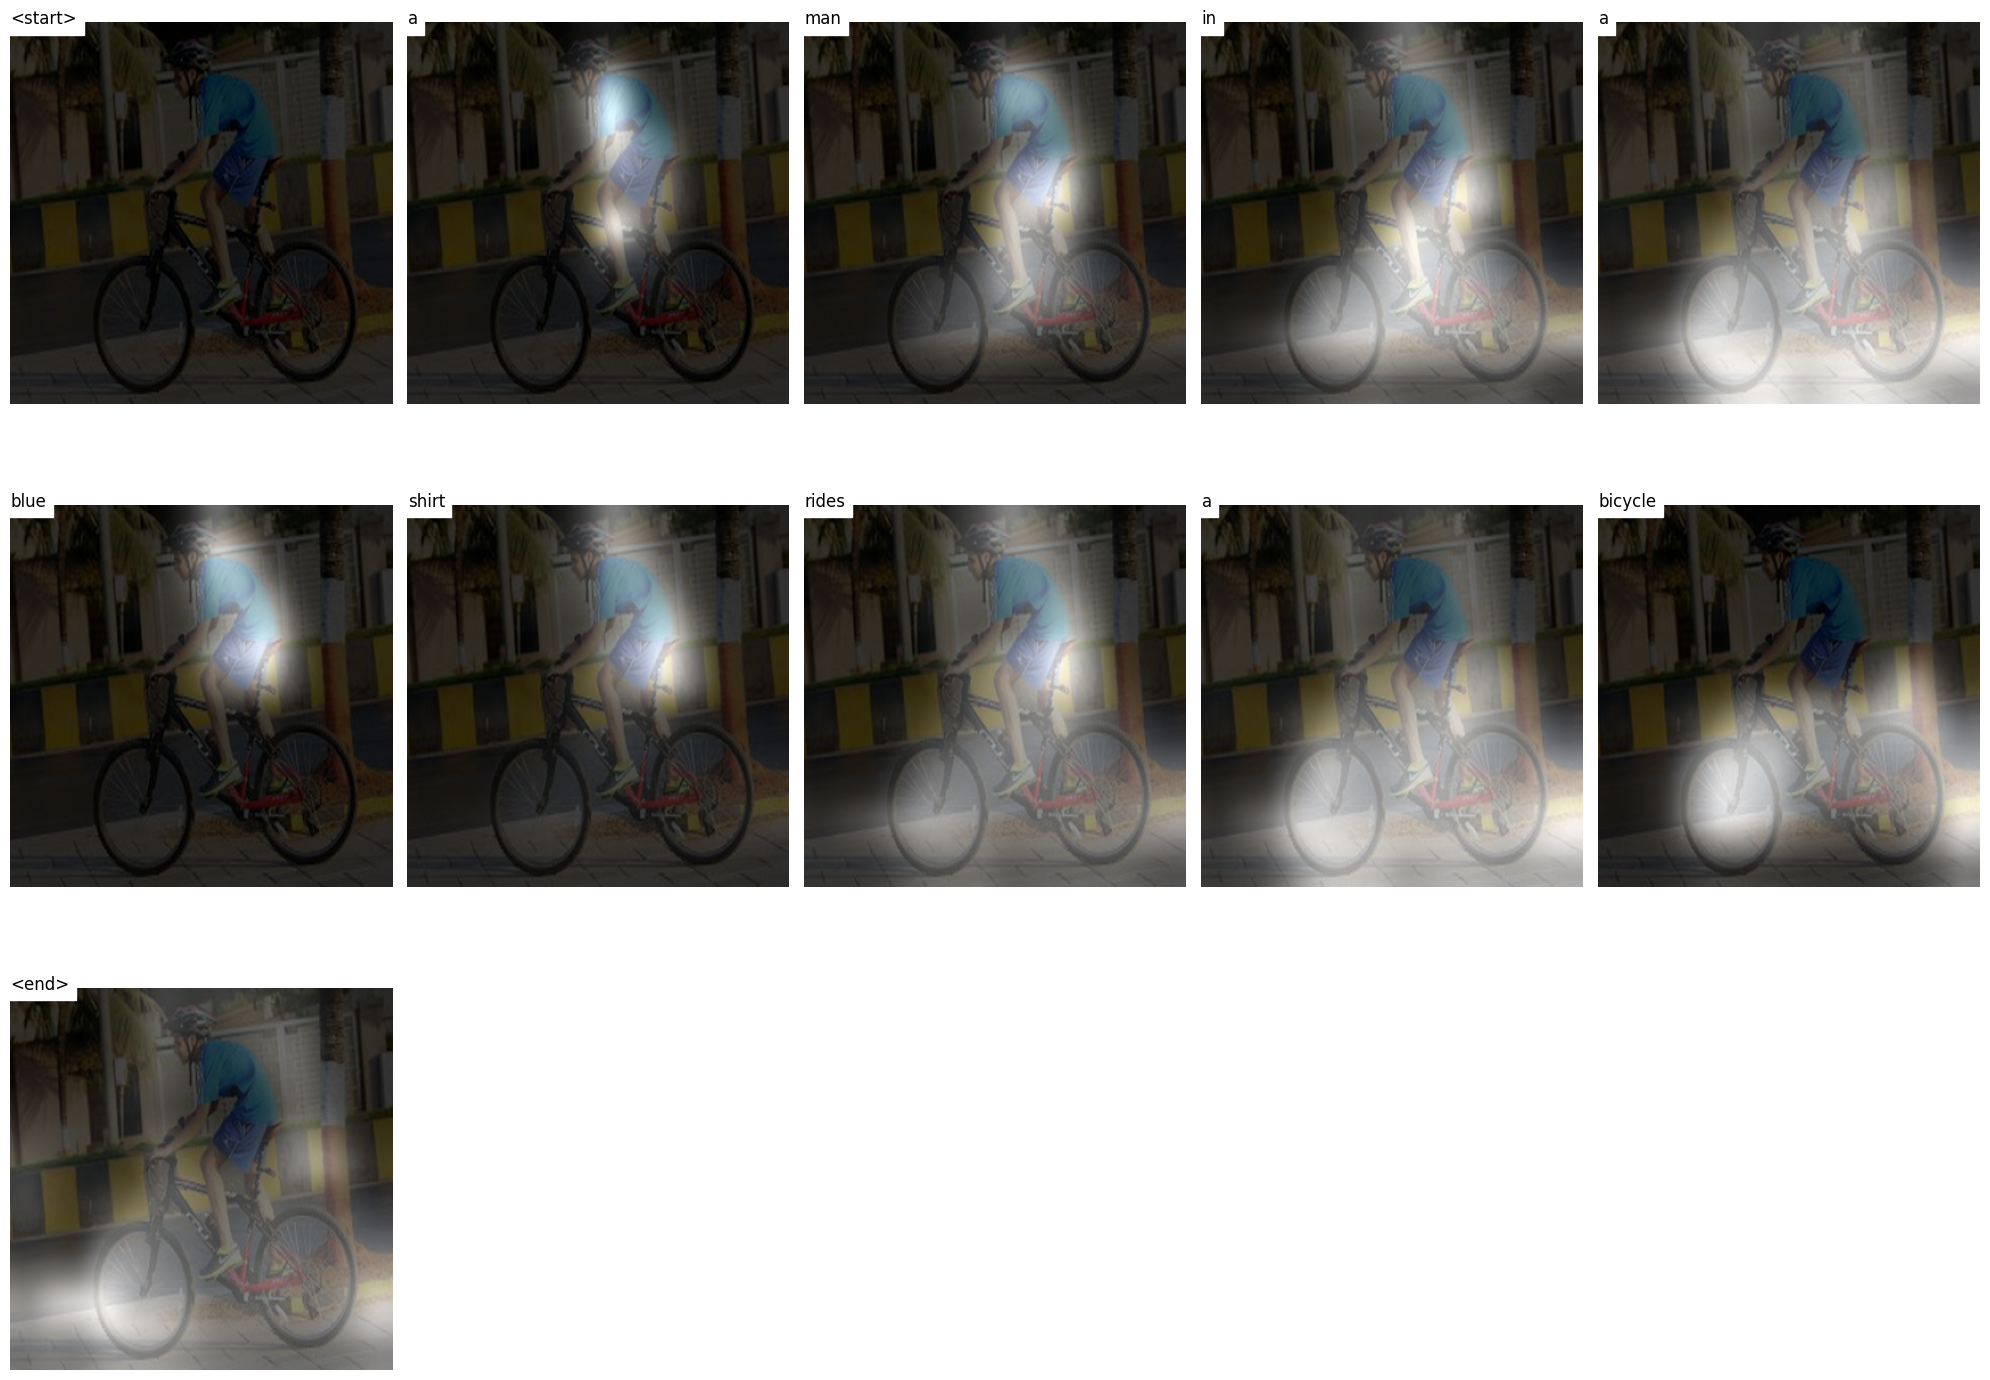

In [17]:
checkpoint_path='/kaggle/working/Image-Captioning/BEST_checkpoint_flickr8k_5_cap_per_img_5_min_word_freq.pth.tar'
word_map='/kaggle/working/captioning-dataset/Flickr8k_Dataset/WORDMAP_flickr8k_5_cap_per_img_5_min_word_freq.json'
img='/kaggle/working/Image-Captioning/test_result/test2.jpg'
beam_size = 5

# Load checkpoint and models
checkpoint = torch.load(checkpoint_path, map_location=str(device))
decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

# Load word map
with open(word_map_file, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

# Generate caption and attention
seq, alphas = caption_image_beam_search(encoder, decoder, img, word_map, beam_size)
alphas = torch.FloatTensor(alphas)

# Visualize attention
visualize_att(img, seq, alphas, rev_word_map, smooth=True)

## 5) Model Evaluation

In [19]:
def evaluate(beam_size):
    vocab_size = len(word_map)
    loader = torch.utils.data.DataLoader(
        CaptionDataset(data_folder, data_name, 'TEST', transform=transforms.Compose([normalize])), batch_size=1, shuffle=True, num_workers=1, pin_memory=True)

    references = list()
    hypotheses = list()

    for i, (image, caps, caplens, allcaps) in enumerate(
            tqdm(loader, desc="EVALUATING AT BEAM SIZE " + str(beam_size))):

        k = beam_size
        image = image.to(device)  

        encoder_out = encoder(image) 
        enc_image_size = encoder_out.size(1)
        encoder_dim = encoder_out.size(3)

        encoder_out = encoder_out.view(1, -1, encoder_dim)  
        num_pixels = encoder_out.size(1)

        encoder_out = encoder_out.expand(k, num_pixels, encoder_dim)  

        k_prev_words = torch.LongTensor([[word_map['<start>']]] * k).to(device) 

        seqs = k_prev_words 
        top_k_scores = torch.zeros(k, 1).to(device)  

        complete_seqs = list()
        complete_seqs_scores = list()

        step = 1
        h, c = decoder.init_hidden_state(encoder_out)

        while True:

            embeddings = decoder.embedding(k_prev_words).squeeze(1)  

            awe, _ = decoder.attention(encoder_out, h)

            gate = decoder.sigmoid(decoder.f_beta(h))  
            awe = gate * awe

            h, c = decoder.decode_step(torch.cat([embeddings, awe], dim=1), (h, c)) 

            scores = decoder.fc(h) 
            scores = F.log_softmax(scores, dim=1)

            scores = top_k_scores.expand_as(scores) + scores  

            if step == 1:
                top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)  
            else:
                top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True) 

            prev_word_inds = (top_k_words / vocab_size).long() 
            next_word_inds = (top_k_words % vocab_size).long()  

            seqs = torch.cat([seqs[prev_word_inds], next_word_inds.unsqueeze(1)], dim=1)  

            incomplete_inds = [ind for ind, next_word in enumerate(next_word_inds) if
                               next_word != word_map['<end>']]
                  
            complete_inds = list(set(range(len(next_word_inds))) - set(incomplete_inds))

            if len(complete_inds) > 0:
                complete_seqs.extend(seqs[complete_inds].tolist())
                complete_seqs_scores.extend(top_k_scores[complete_inds])
            if len(incomplete_inds) == 0: 
                break    
            k -= len(complete_inds)  

            if k == 0:
                break
            seqs = seqs[incomplete_inds]
            h = h[prev_word_inds[incomplete_inds]]
            c = c[prev_word_inds[incomplete_inds]]
            encoder_out = encoder_out[prev_word_inds[incomplete_inds]]
            top_k_scores = top_k_scores[incomplete_inds].unsqueeze(1)
            k_prev_words = next_word_inds[incomplete_inds].unsqueeze(1)

            if step > 50:
                break
            step += 1

        if len(complete_seqs_scores) == 0:
            i = top_k_scores.argmax().item()  
            seq = seqs[i].tolist()
        else:#
            i = complete_seqs_scores.index(max(complete_seqs_scores))
            seq = complete_seqs[i]

        img_caps = allcaps[0].tolist()
        img_captions = list(
            map(lambda c: [w for w in c if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}],
                img_caps)) 
        references.append(img_captions)

        hypotheses.append([w for w in seq if w not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}])

        assert len(references) == len(hypotheses)

    bleu4 = corpus_bleu(references, hypotheses)
    print(f"BLEU-4 Score: {bleu4:.4f}")

    return 

### evaluate testset

In [20]:
beam_size=5
evaluate(beam_size)

EVALUATING AT BEAM SIZE 5: 100%|██████████| 5000/5000 [03:23<00:00, 24.56it/s]


BLEU-4 Score: 0.2211
